# Perform a looping with a quadrotor

# Goal of the project

The goal of this project is to control a 2D quadrotor to get it to perform acrobatic moves. The controller will be designed using an SQP solver.

Please submit your code as a runnable Jupyter Notebook.

## 2D quadrotor

The quadrotor is depicted in the following figure
<img src='quadrotor.png' width="300">


The quadrotor model is written as
$$\begin{align} 
\dot{p_x} &= v_x\\
m \dot{v}_x &= - (u_1 + u_2) \sin \theta \\ 
\dot{p_y} &= v_y\\
m \dot{v}_y &= (u_1 + u_2) \cos \theta  - m g\\
\dot{\theta} &= \omega\\
I \dot{\omega} &= r (u_1 - u_2) \end{align}$$
where $p_x$ is the horizontal and $p_y$ the vertical positions of the quadrotor and $\theta$ is its orientation with respect to the horizontal plane. $v_x$ and $v_y$ are the linear velocities and $\omega$ is the angular velocity of the robot. $u_1$ and $u_2$ are the forces produced by the rotors (our control inputs). $m$ is the quadrotor mass, $I$ its moment of inertia (a scalar), $r$ is the distance from the center of the robot frame to the propellers and $g$ is the gravity constant. To denote the entire state, we will write $x = [p_x, v_x, p_y, v_y, \theta, \omega]^T$ - we will also write $u = [u_1, u_2]^T$.

The module ```quadrotor.py``` defines the problem and provides all the useful information about the robot and methods to simulate and animate it as shown below.

You can access the different parameters of the model in the following way:

In [1]:
import quadrotor

print("Mass    =", quadrotor.MASS)
print("Length  =", quadrotor.LENGTH)
print("Inertia =", quadrotor.INERTIA)
print("Dt      =", quadrotor.DT)
print("state size   =", quadrotor.DIM_STATE)
print("control size =", quadrotor.DIM_CONTROL)

Mass    = 0.45
Length  = 0.14
Inertia = 0.09
Dt      = 0.04
state size   = 6
control size = 2




## Part 1 - Setting up the trajectory optimization problem (50 points)
1. Discretize the system dynamics using Euler's method seen in class - write the time discretization step as $\Delta t$ (use symbols not numbers for the mass, etc)
2. We would like the quadrotor to perfom a looping (i.e. a back or front flip). Find and implement a suitable cost function to perform a looping and add constraints to maintain the thrust of each rotor between $0$ and $10$. Solve the problem using your own implementation of a SQP with a long horizon to ensure that you can do a looping.
3. Show plots of all the states and controls of the robot as a function of time. Plot the value of $\alpha$ (during line search) at each iteration of the solver as well as the amount of constraint violation per iteration and the cost per iteration of the solver (also useful to help you debug).
5. Describe your design choices (in a concise manner) in the report.

To visualize the trajectory, use the ```quadrotor.animate_robot``` function and show the animation (show the plots in your report).

### Tips to implement a SQP solver
1. Write down the algorithm (in words not in code), i.e. write all the steps you need to take
2. Write the gradient of the running cost at a given guess $\bar{x} = [{\bar{p}_x}_0, {\bar{v}_x}_0, {\bar{p}_y}_0, {\bar{v}_{y}}_0, \bar{\theta}_0, \bar{\omega}_0, {\bar{u}_1}_0, {\bar{u}_2}_0, \dots, {\bar{p}_x}_N, {\bar{v}_x}_N, {\bar{p}_y}_N, {\bar{v}_{y}}_N, \bar{\theta}_N, \bar{\omega}_N, {\bar{u}_1}_N, {\bar{u}_2}_N,]^T$, i.e. for a given value of these variables and implement a function that computes it
3. Write the Hessian of the running cost at a given guess $\bar{x}$ and implement a function that computes it
4. Assume that the Hessian of the constraints is 0 (i.e. ignore the second order derivatives of the constraints)
5. Write a linear approximation of the constraints at a given guess $\bar{x}$ in a form $G(\bar{x}) \Delta x = g(\bar{x})$ (don't forget the constant terms in g) where $\Delta x$ represents a small variation around $\bar{x}$ and implement a function that computes both $G$ and $g$.
6. Use these functions to setup the inner QP of the SQP (use the library from HW2 to solve the QP).
7. Implement a function that computes the amount of constraint violation for the nonlinear constraints (not the linearized one), i.e. the sum of the absolute values of all the constraints (i.e. assuming constraints of the form $c(x) = 0$ we want to compute $|c(x)|$).
8. Implement a filter linear search to test if a step should be accepted. You will implement the (simplified) filter line search explained below.
9. Terminate the algorithm when you either reached the maximum number of iterations (e.g. 100) or when the KKT optimality conditions are satisfied (within a small margin, e.g. $10^{-4}$).

Once you have a solution, make sure to check that it satisfies the constraints! You can display the robot using the ```animate_robot``` function.

#### (Simple) filter linear search
Once you have a potential step $\textrm{step}_x$, you need to find a step $\alpha$ to update your guess of the solution $x_{guess}$. We will accept a step that either reduces the amount of constraint violation or reduces the cost.

Let's denote $f(x)$ the cost at $x$ and $|c(x)|$ the amount of constraint violation at $x$. Initialize the variable $f_{best} = \infty$ and $c_{best}=\infty$ at the beginning of the SQP. 

Then do the following during the line search.
1. Set $\rho$ to a number between 0 and 1 (e.g. 0.5) and set $\alpha = 1$
2. If $f(x_{guess} + \alpha \textrm{step}_x) < f_{best}$ then set $f_{best} \leftarrow f(x_{guess} + \alpha \textrm{step}_x)$ and accept the step

   Or 

   If $|c(x_{guess} + \alpha \textrm{step}_x)| < c_{best}$ then set $c_{best} \leftarrow |c(x_{guess} + \alpha \textrm{step}_x)|$ and accept the step
3. If the step was not accepted set $\alpha \leftarrow \rho \alpha$ and go back to Step 2.
4. If the step was accepted update the guess $x_{guess} \leftarrow x_{guess} + \alpha \textrm{step}_x$

## Part 2 - Model predictive control (MPC) (50 points)
1. Use the trajectory optimization method from Part I to design a MPC controller and test it using the simulator below (you may need to use a shorter horizon). In particular, verify that it can handle perturbations by calling the ```quadrotor.simulate``` function with ```disturbance = True``` (when setting disturbance to True, the simulator will generate a random perturbation every 1 second). Simulate your controller for 10 seconds, plot the state anc control evolution.
2. Explain your intended design in the report, including the cost function and found control law

The ```quadrotor.simulate``` function takes as an input an initial state, a controller, the number of discrete time steps and a boolean value to indicate the presence of perturbation. The controller has to be a function taking as an input a state and time index and outputting a control vector.

## Bonus (10 points)
Add a state constraint to perform the looping while maintening a positive altitude. Use the origin as an initial state.

In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation
import IPython

def controller(x, t):
    return np.zeros(2)

x_init = np.array([0, 0, 0., 0 ,0, 0])
horizon_length = 100
t, state, u = quadrotor.simulate(x_init, controller, horizon_length, disturbance=True)
quadrotor.animate_robot(state, u)

Your browser does not support the video tag.

### Creating functions to advance Dynamics and getting Constraint Violations, Creating Equality and Inequality Matrices

In [ ]:
# N=100
dt=quadrotor.DT
# X=np.zeros((N,6))
m=quadrotor.MASS
grr=9.81
r=quadrotor.LENGTH
I=quadrotor.INERTIA


def dynnamics_next(X_cur): # x is n,6 u is n-1,2
    global  dt,m,grr,r,I,x_init
    X=X_cur.copy()
    k8=(np.arange(N-1))*8 
    X[k8+8+0] = X[k8+0]+X[k8+1]*dt # X1 is X next for X0 *, and X1 * is current n+1
    X[k8+8+1]=   X[k8+1] - (X[k8+6]+X[k8+7])*np.sin(X[k8+4])*dt/m
    X[k8+8+2] =  X[k8+2]+X[k8+3]*dt
    X[k8+8+3]=   X[k8+3] + ((X[k8+6]+X[k8+7])*np.cos(X[k8+4])-m*grr)*dt/m
    X[k8+8+4] =  X[k8+4]+X[k8+5]*dt
    X[k8+8+5]=   X[k8+5]+(r*dt/I)*(X[k8+6]-X[k8+7])
    # gamma is Fx* (which is xnext) - Xnext* , so ,its X1 (Xnext) , X_cur1 (X1*) , for X[0] 
    # for X[n] , gamma is what? we only go unti N-1!
    filt=np.arange(8,X_cur.shape[0])
    gamma=(X-X_cur)[filt[(filt % 8) < 6]] ##Gives the Constraints Violation Error

    return X,gamma

def get_Constraints(X_cur):
    global  dt,m,grr,r,I,x_init,N
    X,gamma=dynnamics_next(X_cur)
    G_full=np.zeros((N * 6, N * 2+N*6))
    
    # B_full = np.zeros((N * 6, N * 2))
    # A_full = np.eye(N * 6)
    k = np.arange(N-1)
    k6=(np.arange(N-1)+1)*6
    k8=(np.arange(N-1))*8
    k8f=k8 #(np.arange(N))*8
    k8b=(np.arange(N-1))*8+6
    k8i=(np.arange(N-1))*8+6+2  
    coss=np.cos(X_cur[k8f+4])
    sinn=np.sin(X_cur[k8f+4])
    #filling A
    G_full[k6+0,k8+1]=dt
    G_full[k6+2,k8+3]=dt
    G_full[k6+4,k8+5]=dt
    G_full[k6+1,k8+4]= -(dt/m)*(X_cur[k8f+6]+X_cur[k8f+7])*coss[k]
    G_full[k6+3,k8+4]= -(dt/m)*(X_cur[k8f+6]+X_cur[k8f+7])*sinn[k]
    G_full[k6+0,k8+0]=1.0
    G_full[k6+1,k8+1]=1.0
    G_full[k6+2,k8+2]=1.0
    G_full[k6+3,k8+3]=1.0
    G_full[k6+4,k8+4]=1.0
    G_full[k6+5,k8+5]=1.0
    #filling B
    G_full[k6+1,k8+6]=-(dt/m)*sinn[k]
    G_full[k6+1,k8+7]=-(dt/m)*sinn[k]
    G_full[k6+3,k8+6]=(dt/m)*coss[k]
    G_full[k6+3,k8+7]=(dt/m)*coss[k]
    G_full[k6+5,k8+6]= r*dt/I
    G_full[k6+5,k8+7]=-r*dt/I
    #filling I
    G_full[k[:6],k[:6]]=1
    G_full[k6+0,k8i+0]=-1
    G_full[k6+1,k8i+1]=-1
    G_full[k6+2,k8i+2]=-1
    G_full[k6+3,k8i+3]=-1
    G_full[k6+4,k8i+4]=-1
    G_full[k6+5,k8i+5]=-1

    g=np.zeros((N * 6))
    g[:6]=x_init-X_cur[:6]
    g[6:]= -gamma #.flatten()+

    #Inequality:
    # 5 constraings, so Dx<e  , e is shape N*5, D is shape  N*5,N*8
    D=np.zeros((N *5 , N * 8))
    e=np.zeros((N*5))
    k5 = np.arange(N)*5
    k8=np.arange(N)*8

    e[k5+0]=X_cur[k8+6]
    e[k5+1]=X_cur[k8+7]
    e[k5+2]=10-X_cur[k8+6]
    e[k5+3]=10-X_cur[k8+7]
    e[k5+4]=X_cur[k8+2] #+1e-15
    

    D[k5+0,k8+6]=-1
    D[k5+1,k8+7]=-1
    D[k5+2,k8+6]=1
    D[k5+3,k8+7]=1
    D[k5+4,k8+2]=-1
    

    return X,G_full,g,D,e




### Creating the Functions for Creating the Cost Matrix, Calculating Cost, Line Search

In [37]:

def make_Cost_Matrix(N):
    k = np.arange(N)
    k8=np.arange(N)*8
    Ca=np.zeros((8*N,8*N))
    Ca[k8+0,k8+0]=4 #x cost 
    Ca[k8+2,k8+2]=5 #y cost 
    Ca[k8+1,k8+1]=3 #vx cost
    Ca[k8+3,k8+3]=3 #vy cost
    Ca[k8+5,k8+5]=1 #w cost
    Ca[k8+4,k8+4]=6#theta cost 
    Ca[k8+6,k8+6]=3 #u1
    Ca[k8+7,k8+7]=3 #u21
   
   # Terminal Costs!
    last= (N-1)*8
    Ca[last+4,last+4]=6 #theta 
    Ca[last+1,last+1]=20 #vx
    Ca[last+3,last+3]=20 #vy 
    Ca[last+0,last+0]=3 #x
    Ca[last+2,last+2]=3 #y
    return Ca



def Cost_calc(X,Xd,Ca):
    xc=X-Xd
    return 0.5* xc.T @ Ca @ xc    #+ xt.T @ Ch @ xt



def line_search(X,delX,Xd,Ca,fb,cb,alpha=1,):
    ro=0.5
    xt,gamma=dynnamics_next(X+alpha*delX)
    const_cost=np.linalg.norm(gamma,ord=1)
    f_cost=Cost_calc(X+alpha*delX,Xd,Ca)

    if alpha<1e-15:
        return 0,f_cost,const_cost
    if f_cost<=fb:
        fb=f_cost
        return alpha,f_cost,const_cost
    elif const_cost<=cb:
        cb=const_cost
        return alpha,f_cost,const_cost
    else:
        alpha*=ro
        return line_search(X,delX,Xd,Ca,fb,cb,alpha)


In [38]:
from qpsolvers import solve_qp

###  Running the SQP:

In [ ]:
hover=m*grr/2
print(m,grr)


N=100
Ca=make_Cost_Matrix(N)

#Specifying the TARGET HERE to 2pi, for a rotation
Xd=np.tile(np.array([0,0,0.5,0,2*np.pi,0,hover,hover]),N) #hover thrust
###########################################
k = np.arange(N)*8
X=np.zeros(N*8) #initialising
fb=float('inf')
cb=float('inf')
x_init=np.zeros(6)
a_list=[]
c_list=[]
C_list=[]

for i in range(100):
    xt,A,b,G,h=get_Constraints(X)
    P=Ca
    q=Ca @ (X-Xd)
    delx = solve_qp(P=P, q=q, A= A,b= b,G=G,h=h, solver="cvxopt")
    if delx is None:
        print("Solver Returing None!")
        break
    alpha,cr,crr=line_search(X,delx,Xd,Ca,fb,cb,alpha=1)
    c_list.append(crr)
    C_list.append(cr)
    a_list.append(alpha)
    print("Iteration: ",i, "delx sum: ",np.sum(np.abs(delx))," alpha: ",alpha)
    X+=alpha*delx
    if alpha<1e-6 or np.sum(np.abs(delx))<1e-6:
        break
    

#SIMULATING
def controller(x, t):
    global U
    return U[t*2:t*2+2]
mask = (np.arange(Ca.shape[0]) % 8) >= 6
U=X[mask]
x_init = np.array([0, 0, 0., 0 ,0, 0])
horizon_length = N
t, state, u = quadrotor.simulate(x_init, controller, horizon_length, disturbance=False)
quadrotor.animate_robot(state, u)


0.45 9.81
Iteration:  0 delx sum:  1135.9482852534338  alpha:  1
Iteration:  1 delx sum:  629.6705821079661  alpha:  1
Iteration:  2 delx sum:  199.24582590362968  alpha:  1
Iteration:  3 delx sum:  119.15330976105756  alpha:  1
Iteration:  4 delx sum:  71.7613704045213  alpha:  1
Iteration:  5 delx sum:  61.17217228853043  alpha:  1
Iteration:  6 delx sum:  46.81097381938305  alpha:  1
Iteration:  7 delx sum:  31.892157330952074  alpha:  1
Iteration:  8 delx sum:  18.305098874302804  alpha:  1
Iteration:  9 delx sum:  8.699219024513322  alpha:  1
Iteration:  10 delx sum:  4.233846687099389  alpha:  1
Iteration:  11 delx sum:  1.6571206839526522  alpha:  1
Iteration:  12 delx sum:  0.6835331413691701  alpha:  1
Iteration:  13 delx sum:  0.28458285233222935  alpha:  1
Iteration:  14 delx sum:  0.11828612378206332  alpha:  1
Iteration:  15 delx sum:  0.049193390762736634  alpha:  1
Iteration:  16 delx sum:  0.020452729885438642  alpha:  1
Iteration:  17 delx sum:  0.008503741322731245  a

Your browser does not support the video tag.

## PLOTTING RESULTS OF THE SQP:

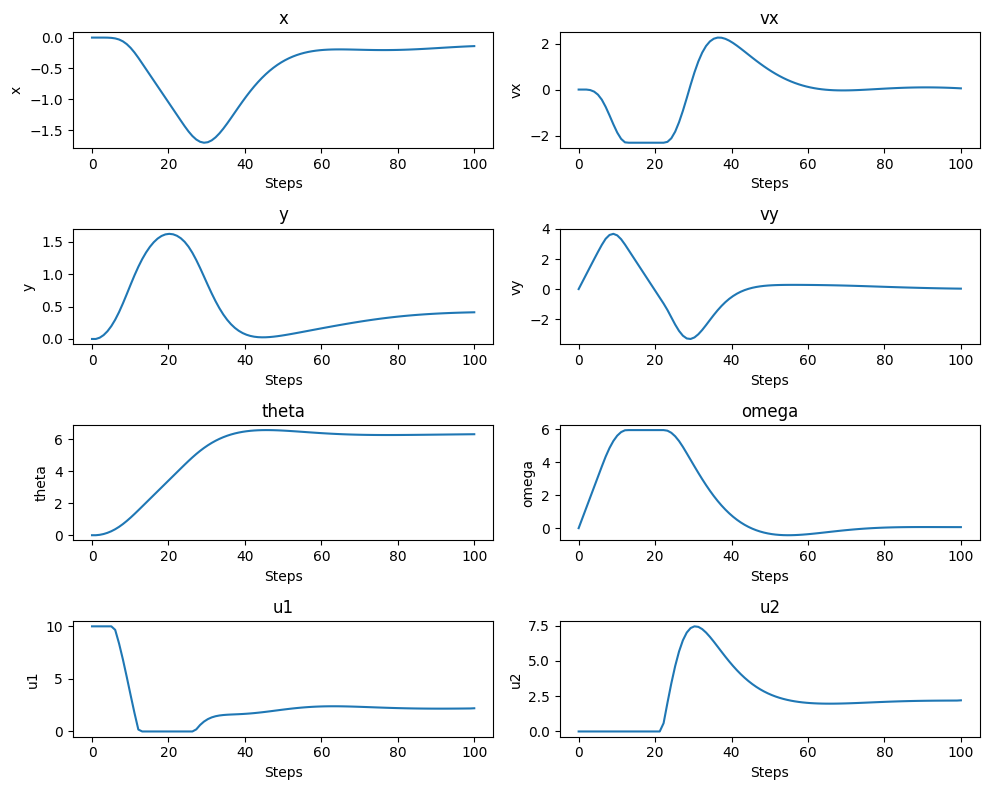

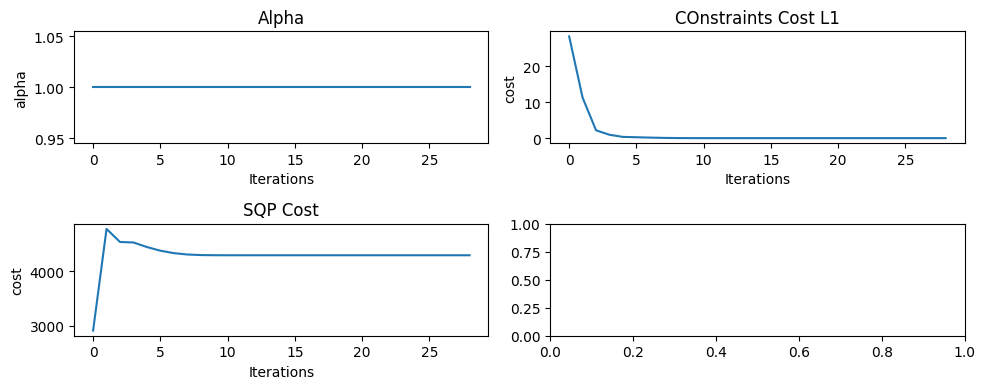

In [40]:
time = np.linspace(0, N, N)
y=X[:N*8].copy()
y = y.reshape((N, 8))
labels = ['x', 'vx', 'y', 'vy', 'theta', 'omega', 'u1', 'u2']

fig, axes = plt.subplots(4, 2, figsize=(10, 8))
axes = axes.ravel() # Flatten the 4x2 array of axes
y[:,0]=y[:,0]
y[:,2]=y[:,2]
for i in range(8):
    axes[i].plot(time, y[:, i])
    axes[i].set_title(labels[i])
    axes[i].set_xlabel('Steps')
    axes[i].set_ylabel(labels[i])

plt.tight_layout()
a_list=np.array(a_list)
c_list=np.array(c_list)
C_list=np.array(C_list)
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
axes = axes.ravel() 
it=np.arange(a_list.shape[0])
axes[0].plot(it, a_list)
axes[0].set_title("Alpha")
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel("alpha")
axes[1].plot(it, c_list)
axes[1].set_title("COnstraints Cost L1")
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel("cost")
axes[2].plot(it, C_list)
axes[2].set_title("SQP Cost")
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel("cost")
plt.tight_layout()

## RUNNING THE MPC:

In [ ]:
hover=m*grr/2
print(m,grr)
N=35
Ca=make_Cost_Matrix(N)
k = np.arange(N)*8
x_init=np.zeros(6)
state_list=[]
X=np.zeros(N*8)
#SPECIFIYING TARGET HERE
Xd=np.tile(np.array([0,0,1,0,2*np.pi,0,hover,hover]),N)
Xd[-6]=0
#MAIN CONTROLLER!
def controller(x, t):
    global X,x_init,N,Xd
    hover=m*grr/2
    k = np.arange(N)*8
    fb=float('inf')
    cb=float('inf')
    X[:-8] = X[8:]
    X[:6]=x
    x_init=x
    print("Controller itr t: ",t)
    fb=float('inf')
    cb=float('inf')
    for i in range(5): # Similar to MPPI, this still works
        xt,A,b,G,h=get_Constraints(X)
        P=Ca
        q=Ca @ (X-Xd)
        delx = solve_qp(P=P, q=q, A= A,b= b,G=G,h=h ,solver="cvxopt")
        if delx is None:
            print("Solver Failed! ")
            break
            # print("A eigen :",np.linalg.eigvals(A) )
            
        
        
        alpha,uc,gammas=line_search(X,delx,Xd,Ca,fb,cb,alpha=1)
        # print("gamma:" , gammas)
        # print("Iteration: ",i, "delx sum: ",np.sum(np.abs(delx))," alpha: ",alpha)
        X+=alpha*delx
        if alpha<1e-6 or np.sum(np.abs(delx))<1e-6:
            print("Dead Gradient: ","Iteration: ",i, "delx sum: ",np.sum(np.abs(delx))," alpha: ",alpha)
            break
    return X[6:8]

#Running the Simulation
x_init = np.array([0, 0, 0., 0 ,0, 0])
horizon_length = 250  #dt=0.04, l*dt=10, l=10/0.04 1000/4=250
t, state, u = quadrotor.simulate(x_init, controller, horizon_length, disturbance=True)
quadrotor.animate_robot(state, u)





0.45 9.81
Controller itr t:  0
Controller itr t:  1
Controller itr t:  2
Controller itr t:  3
Controller itr t:  4
Controller itr t:  5
Controller itr t:  6
Controller itr t:  7
Controller itr t:  8
Controller itr t:  9
Controller itr t:  10
Controller itr t:  11
Controller itr t:  12
Controller itr t:  13
Controller itr t:  14
Controller itr t:  15
Controller itr t:  16
Controller itr t:  17
Controller itr t:  18
Controller itr t:  19
Controller itr t:  20
Controller itr t:  21
Controller itr t:  22
Controller itr t:  23
Controller itr t:  24
Controller itr t:  25
Controller itr t:  26
Controller itr t:  27
Controller itr t:  28
Controller itr t:  29
Controller itr t:  30
Controller itr t:  31
Controller itr t:  32
Controller itr t:  33
Controller itr t:  34
Controller itr t:  35
Controller itr t:  36
Controller itr t:  37
Controller itr t:  38
Controller itr t:  39
Controller itr t:  40
Controller itr t:  41
Controller itr t:  42
Controller itr t:  43
Controller itr t:  44
Controller

Your browser does not support the video tag.

### Plotting MPC Results

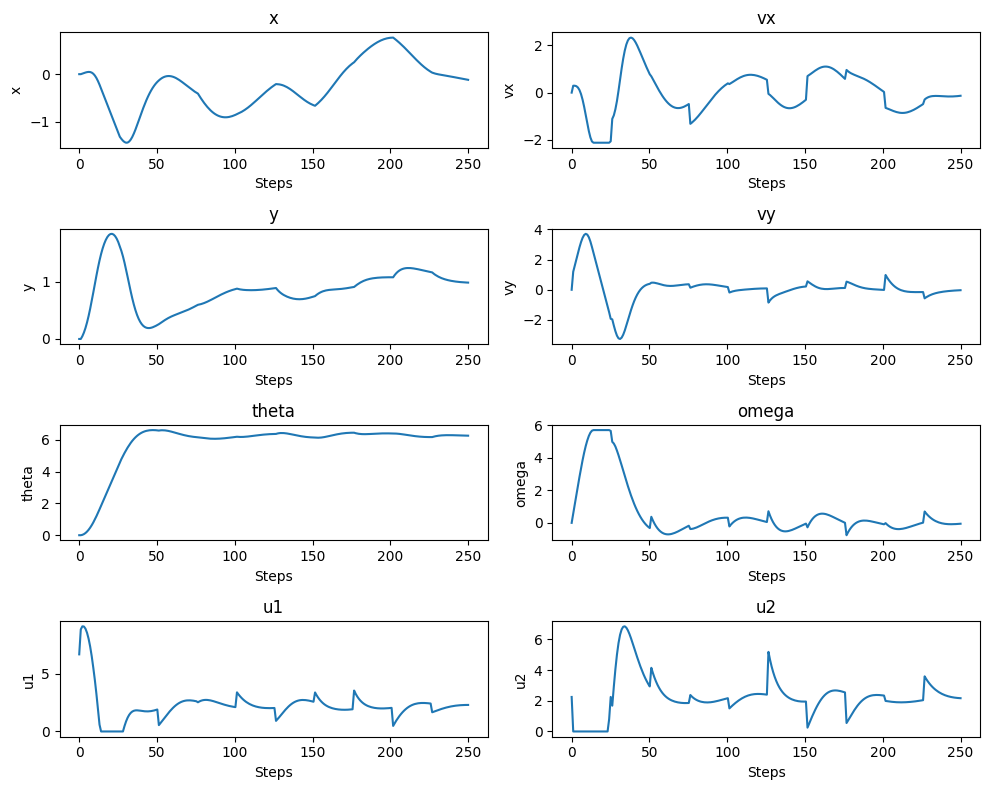

In [43]:
X_res=np.concatenate((state[:,:horizon_length],u),axis=0)
N=X_res.shape[1]
time = np.linspace(0, N, N)
y=X_res.copy()
y = y.T #reshape((N, 8))
labels = ['x', 'vx', 'y', 'vy', 'theta', 'omega', 'u1', 'u2']

fig, axes = plt.subplots(4, 2, figsize=(10, 8))
axes = axes.ravel() # Flatten the 4x2 array of axes
y[:,0]=y[:,0]
y[:,2]=y[:,2]
for i in range(8):
    axes[i].plot(time, y[:, i])
    axes[i].set_title(labels[i])
    axes[i].set_xlabel('Steps')
    axes[i].set_ylabel(labels[i])

plt.tight_layout()
